In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import the data and find it's shape
df = pd.read_csv("../data/raw/data.csv")
df.shape

(7043, 21)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# From above we found that many columns have values which are binary in nature, like 'yes','no' or 'male', 'female'. So, we will replace them with simple 0 and 1
# and turn them into categorical variable

binary_cols = df[['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']].columns
df[binary_cols] = df[binary_cols].replace(
    {
        'Yes' : 1,
        'No' : 0,
        'Male' : 1,
        'Female' : 0,
    }
)

In [6]:
#Now there are some columns which are more than two unique values and those columns we will one hot encode
mult_cat_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport',
                    'StreamingTV','StreamingMovies','Contract','PaymentMethod']

df = pd.get_dummies(df, columns = mult_cat_cols, drop_first = True)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,...,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,False,False,False,False,False,False,False,False,True,False


In [7]:
#Let's drop customerID columns because it's not necessary for us

df = df.drop('customerID', axis = 1)

In [8]:
#Notice the "TotalCharges" column is a string but the values are all numbers, so let's change it to numerical

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

In [9]:
#Now convert all bool columns into 0/1
bool_col = df.select_dtypes(include = 'bool').columns
df[bool_col] = df[bool_col].astype(int)

In [10]:
obj_col = df.select_dtypes(include = 'object').columns
df[obj_col] = df[obj_col].astype(int)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  MultipleLines_Y

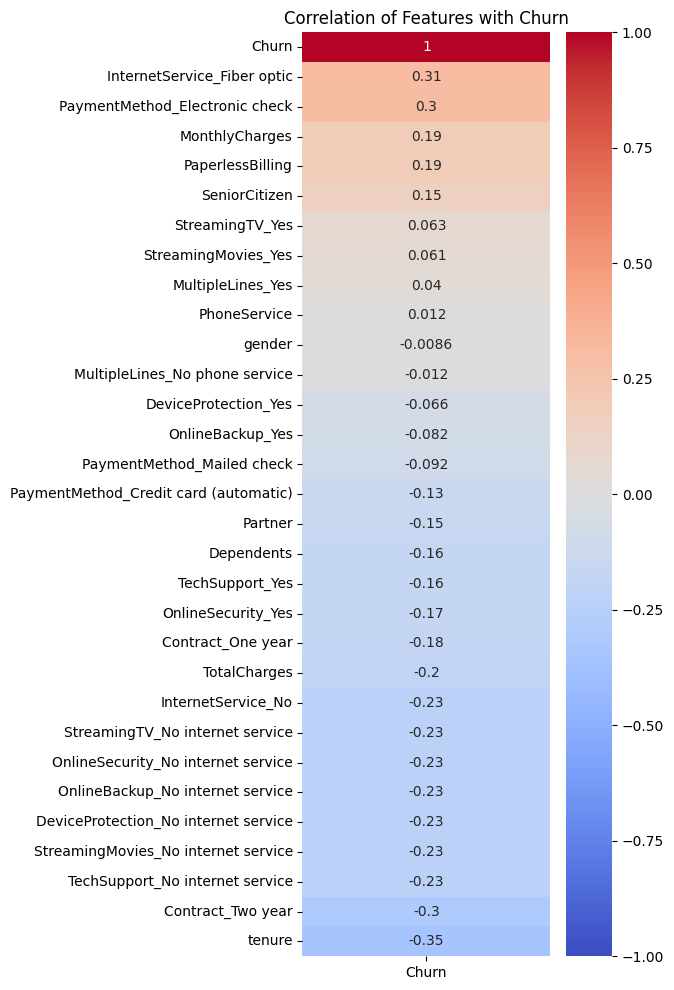

In [12]:
#Now let's see the correlation matrix, and figure out how the churn column relates with other colums

corr_matrix = df.corr(numeric_only = True)
churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)

plt.figure(figsize = (4,12))
sns.heatmap(churn_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Features with Churn')
plt.show()


In [13]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')

In [14]:
df['No_Internet_Service'] = (df['MultipleLines_No phone service'] | df['OnlineSecurity_No internet service'] | df['OnlineBackup_No internet service'] |
                            df['DeviceProtection_No internet service'] | df['TechSupport_No internet service'] | df['StreamingTV_No internet service'] |
                            df['StreamingMovies_No internet service']).astype(int)

In [15]:
drop_cols = [cols for cols in df.columns if 'No internet service' in cols]
df = df.drop(drop_cols, axis =1)

In [16]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes',
       'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'No_Internet_Service'],
      dtype='str')

In [17]:
if 'MultipleLines_No phone service' in df.columns:
    df['No_phone_service'] = df['MultipleLines_No phone service'].astype(int)
    df = df.drop(columns=['MultipleLines_No phone service'])

In [18]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
       'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes',
       'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'No_Internet_Service', 'No_phone_service'],
      dtype='str')

In [19]:
X = df.drop('Churn', axis =1)

In [20]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   MultipleLines_Yes                      7043 non-null   int64  
 10  InternetService_Fiber optic            7043 non-null   int64  
 11  InternetService

In [21]:
#Run VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

In [22]:
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

In [23]:
vif_data = pd.DataFrame()
vif_data['features'] = X.columns

In [24]:
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range (X.shape[1])]

C:\Users\LIPUN\Documents\Deep Learning\ds_env\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [26]:
vif_data = vif_data.sort_values(by='VIF', ascending=False)
vif_data

,features,VIF
11,InternetService_No,inf
23,No_Internet_Service,inf
24,No_phone_service,inf
5,PhoneService,1773.528816
7,MonthlyCharges,866.089640
10,InternetService_Fiber optic,148.500814
17,StreamingMovies_Yes,24.156394
16,StreamingTV_Yes,24.080019
8,TotalCharges,10.811490
4,tenure,7.584453


In [30]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,No_Internet_Service,No_phone_service
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,1,0,1,1
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,1,0,0,0,1,0,0
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,1,0,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,1,0,0,0,0,1,1
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,84.80,1990.50,0,...,1,1,1,1,0,0,0,1,0,0
7039,0,0,1,1,72,1,1,103.20,7362.90,0,...,0,1,1,1,0,1,0,0,0,0
7040,0,0,1,1,11,0,1,29.60,346.45,0,...,0,0,0,0,0,0,1,0,1,1
7041,1,1,1,0,4,1,1,74.40,306.60,1,...,0,0,0,0,0,0,0,1,0,0


In [31]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import lightgbm as lgb
import time


X = df.drop('Churn', axis=1)
y = df['Churn']

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

THRESHOLD = 0.3

In [40]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train,y_train)
prob = rf.predict_proba(X_test)[:,1]
y_pred = (prob>=THRESHOLD).astype(int)
print(classification_report(y_test, y_pred, digits=3))


              precision    recall  f1-score   support

           0      0.885     0.764     0.820      1035
           1      0.526     0.725     0.610       374

    accuracy                          0.754      1409
   macro avg      0.706     0.744     0.715      1409
weighted avg      0.790     0.754     0.764      1409



In [57]:
from sklearn.metrics import precision_score, recall_score, f1_score
prob = rf.predict_proba(X_test)[:, 1]

print("Threshold tuning for random forest")
print(f"{'Thresh':<11}{'Precision':<11}{'Recall':<11}{'f1':<11}")
for thresh in [0.25,0.30,0.35,0.40,0.45,0.50]:
    preds = (prob>=thresh).astype(int)
    prec= precision_score(y_test, preds, pos_label=1)
    rec= recall_score(y_test, preds, pos_label=1)
    f1= f1_score(y_test, preds, pos_label=1)
    print(f'{thresh:<11}{prec:<11.3f}{rec:<11.3f}{f1:<11.3f}')
    

Threshold tuning for random forest
Thresh     Precision  Recall     f1         
0.25       0.506      0.797      0.619      
0.3        0.526      0.725      0.610      
0.35       0.545      0.660      0.597      
0.4        0.574      0.615      0.594      
0.45       0.614      0.570      0.591      
0.5        0.637      0.511      0.567      


In [60]:
from lightgbm import LGBMClassifier
import time
from sklearn.metrics import classification_report


lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

start_train = time.time()
lgbm.fit(X_train,y_train)
train_time = time.time() - start_train
print(f'training time was: {train_time:.4f} seconds')

start_pred = time.time()
prob = lgbm.predict_proba(X_test)[:,1]
y_pred = (prob>=THRESHOLD).astype(int)
pred_time = time.time()-start_pred
print(f'prediction time was: {pred_time:.4f} seconds')

print(classification_report(y_test, y_pred, digits=3))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002306 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
training time was: 0.7395 seconds
prediction time was: 0.0090 seconds
              precision    recall  f1-score   support

           0      0.915     0.700     0.794      1035
           1      0.498     0.821     0.620       374

    accuracy                          0.732      1409
   macro avg      0.706     0.761     0.707      1409
weighted avg      0.804   

In [62]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

# Training timer
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

⏱ Training time: 0.53 seconds
⏱ Prediction time: 0.0100 seconds
              precision    recall  f1-score   support

           0      0.911     0.683     0.781      1035
           1      0.482     0.816     0.606       374

    accuracy                          0.718      1409
   macro avg      0.696     0.749     0.693      1409
weighted avg      0.797     0.718     0.734      1409



In [63]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = xgb.predict_proba(X_test)[:, 1]

print("Threshold tuning for XGBoost")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.466   0.837   0.599   
0.3     0.482   0.816   0.606   
0.35    0.502   0.791   0.614   
0.4     0.511   0.754   0.609   
0.45    0.529   0.727   0.613   
0.5     0.550   0.695   0.614   


In [65]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split

# Objective function for Optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
        "eval_metric": "logloss"
    }
    
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)  # Keep your tuned threshold
    return recall_score(y_test, y_pred, pos_label=1)  # Optimize recall for churners

# Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best Params:", study.best_params)
print("Best Recall:", study.best_value)

C:\Users\LIPUN\Documents\Deep Learning\ds_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-26 18:11:39,996] A new study created in memory with name: no-name-ebf21065-51c7-4329-a1c5-0aac195b1088
[I 2026-04-26 18:11:40,366] Trial 0 finished with value: 0.9117647058823529 and parameters: {'n_estimators': 548, 'learning_rate': 0.01507181209974038, 'max_depth': 3, 'subsample': 0.6061995826229517, 'colsample_bytree': 0.7493084264456593, 'min_child_weight': 10, 'gamma': 0.6855581854689935, 'reg_alpha': 4.87368163855517, 'reg_lambda': 3.8461400443223908}. Best is trial 0 with value: 0.9117647058823529.
[I 2026-04-26 18:11:40,606] Trial 1 finished with value: 0.9010695187165776 and parameters: {'n_estimators': 322, 'learning_rate': 0.036271408034345164, 'max_depth': 5, 'subsample': 0.7698213273123133, 'colsam

Best Params: {'n_estimators': 373, 'learning_rate': 0.02460583067790624, 'max_depth': 9, 'subsample': 0.9999963682581383, 'colsample_bytree': 0.9738547712290048, 'min_child_weight': 6, 'gamma': 3.484474491301067, 'reg_alpha': 3.096451062370739, 'reg_lambda': 1.4432641468931258}
Best Recall: 0.9251336898395722


In [66]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Add the scale_pos_weight and fixed params to the best ones from Optuna
best_params = study.best_params
best_params.update({
    "random_state": 42,
    "n_jobs": -1,
    "scale_pos_weight": scale_pos_weight,
    "eval_metric": "logloss"
})

# Create model from best params
xgb = XGBClassifier(**best_params)

# Training timer
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

⏱ Training time: 0.30 seconds
⏱ Prediction time: 0.0071 seconds
              precision    recall  f1-score   support

           0      0.955     0.576     0.719      1035
           1      0.441     0.925     0.597       374

    accuracy                          0.669      1409
   macro avg      0.698     0.750     0.658      1409
weighted avg      0.819     0.669     0.686      1409

